# Hess–Smith Panel Method — NACA 4412

This notebook is a **working template / scaffold**, not the finished solution.

Goal: implement the Hess–Smith panel method for a NACA 4412 airfoil at  
$$
\alpha = 6^\circ
$$
and then produce the plots and checks requested in the assignment.

## 0. Imports and global settings

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## 1. Parameters

For NACA 4412:

- first digit: $100\epsilon = 4\Rightarrow \epsilon = 0.04$
- second digit: $10p = 4\Rightarrow p = 0.4$
- last two digits: $100\tau = 12\Rightarrow \tau = 0.12$

Use an even number of panels $N$, because the top and bottom surfaces should have the same number of panels.

In [2]:
N = 60
alpha_deg = 6.0
alpha = np.deg2rad(alpha_deg)

epsilon = 0.04   # max camber for NACA 4412
p = 0.4          # position of max camber
tau = 0.12       # thickness

U_inf = 1.0

assert N % 2 == 0, "N must be even."

## 2. NACA 4-digit geometry

TODO:

Write a function that creates $N+1$ nodes around the airfoil.

Required by the task:

- Chebyshev distribution along the x-axis:
  $$
  x_k = \frac{1}{2}\left(1 - \cos\left(\frac{2k\pi}{N}\right)\right),
  \qquad k=0,\ldots,\frac{N}{2}
  $$
- compute the camber line $\bar{Y}(x)$
- compute the thickness function $T(x)$
- compute upper and lower surface coordinates
- order nodes clockwise
- start and end at the trailing edge

In [3]:
def naca4_nodes(N, eps, p, tau, method="moran"):
    """
    Build N+1 clockwise nodes for a 4-digit NACA airfoil.

    eps = first digit / 100
    p   = second digit / 10
    tau = last two digits / 100
    """

    if N % 2 != 0:
        raise ValueError("N must be even.")

    k = np.arange(N // 2 + 1)

    # chebyshev x-points, from leading edge x=0 to trailing edge x=1
    x = 0.5 * (1 - np.cos(2 * np.pi * k / N))

    # thickness coefficient
    if method.lower() == "moran":
        # closed trailing edge, zero thickness at x=1
        a4 = -0.1036
    elif method.lower() == "mason":
        # open trailing edge, small non-zero thickness at x=1
        a4 = -0.1015
    else:
        raise ValueError("method must be 'moran' or 'mason'.")

    # thickness distribution
    yt = 5 * tau * (
        0.2969 * np.sqrt(x)
        - 0.1260 * x
        - 0.3516 * x**2
        + 0.2843 * x**3
        + a4 * x**4
    )

    # camber line and derivative
    yc = np.zeros_like(x)
    dyc_dx = np.zeros_like(x)

    left = x < p
    right = x >= p

    yc[left] = eps / p**2 * (2 * p * x[left] - x[left]**2)
    dyc_dx[left] = 2 * eps / p**2 * (p - x[left])

    yc[right] = eps / (1 - p)**2 * ((1 - 2*p) + 2*p*x[right] - x[right]**2)
    dyc_dx[right] = 2 * eps / (1 - p)**2 * (p - x[right])

    theta = np.arctan(dyc_dx)

    # surface coordinates
    xu = x - yt * np.sin(theta)
    yu = yc + yt * np.cos(theta)

    xl = x + yt * np.sin(theta)
    yl = yc - yt * np.cos(theta)

    # clockwise order: trailing edge upper -> leading edge -> trailing edge lower
    x_nodes = np.concatenate([xl[::-1], xu[1:]])
    y_nodes = np.concatenate([yl[::-1], yu[1:]])

    return x_nodes, y_nodes

### 2.1 Plot discretized airfoil

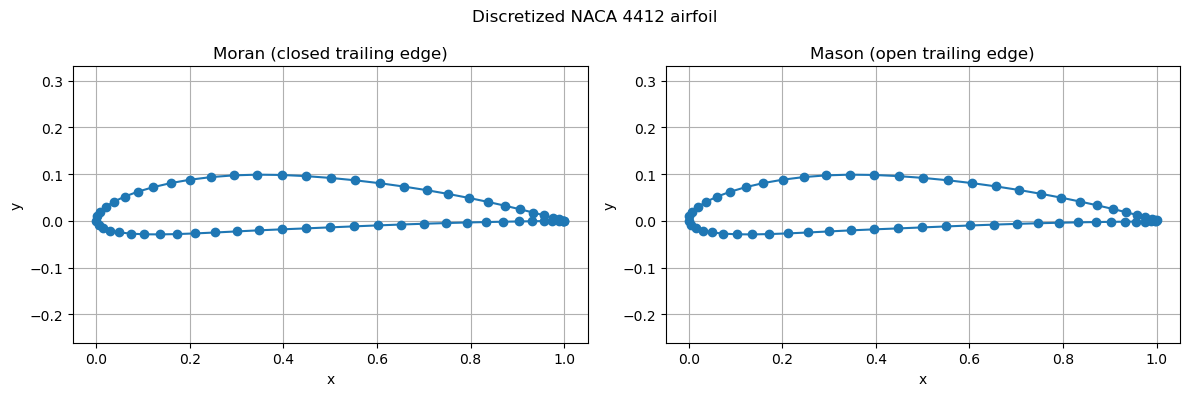

In [4]:
x_moran, y_moran = naca4_nodes(N, epsilon, p, tau, method="moran")
x_mason, y_mason = naca4_nodes(N, epsilon, p, tau, method="mason")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# --- Moran ---
ax[0].plot(x_moran, y_moran, "o-")
ax[0].set_title("Moran (closed trailing edge)")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
ax[0].axis("equal")
ax[0].grid(True)

# --- Mason ---
ax[1].plot(x_mason, y_mason, "o-")
ax[1].set_title("Mason (open trailing edge)")
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")
ax[1].axis("equal")
ax[1].grid(True)

plt.suptitle("Discretized NACA 4412 airfoil")
plt.tight_layout()
plt.show()

## 3. Panel geometry

TODO:

Write a function that computes:

- panel midpoints/control points
- panel lengths
- panel inclination angles or $\sin\theta$, $\cos\theta$

In [5]:
def panel_geometry(x_nodes, y_nodes):
    """
    Compute geometry data for each panel.

    Parameters
    ----------
    x_nodes, y_nodes : arrays
        Coordinates of the N+1 airfoil nodes.

    Returns
    -------
    x_mid, y_mid : arrays
        Coordinates of panel midpoints/control points.
    ds : array
        Panel lengths.
    sin_theta, cos_theta : arrays
        Sine and cosine of panel inclination angles.
    theta : array
        Panel inclination angles in radians.
    """

    # differences between end node and start node of each panel
    dx = x_nodes[1:] - x_nodes[:-1]
    dy = y_nodes[1:] - y_nodes[:-1]

    # panel length
    ds = np.sqrt(dx**2 + dy**2)

    # panel midpoint/control point
    x_mid = 0.5 * (x_nodes[:-1] + x_nodes[1:])
    y_mid = 0.5 * (y_nodes[:-1] + y_nodes[1:])

    # panel inclination
    cos_theta = dx / ds
    sin_theta = dy / ds

    # angle itself, useful for debugging
    theta = np.arctan2(dy, dx)

    return x_mid, y_mid, ds, sin_theta, cos_theta, theta

Number of panels: 60
First panel midpoint: 0.9986043297906112 -1.479292774429895e-05
First panel length: 0.002791497206938688
First panel sin(theta), cos(theta): -0.010598561737798197 -0.9999438336672166


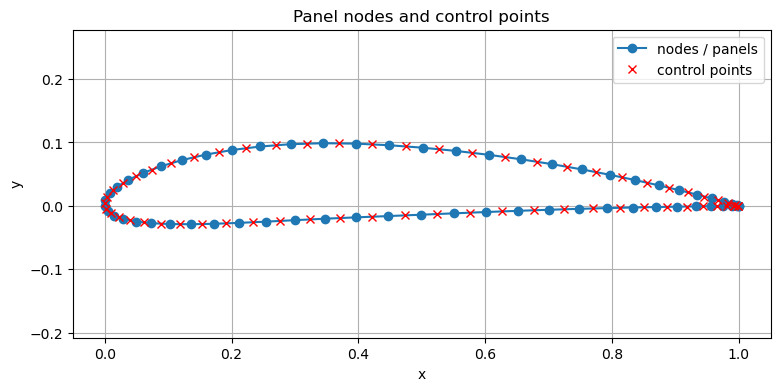

In [6]:
x_nodes, y_nodes = naca4_nodes(N, epsilon, p, tau, method="moran")

x_mid, y_mid, ds, sin_theta, cos_theta, theta = panel_geometry(x_nodes, y_nodes)

print("Number of panels:", len(ds))
print("First panel midpoint:", x_mid[0], y_mid[0])
print("First panel length:", ds[0])
print("First panel sin(theta), cos(theta):", sin_theta[0], cos_theta[0])

plt.figure(figsize=(9, 4))

plt.plot(x_nodes, y_nodes, "o-", label="nodes / panels")
plt.plot(x_mid, y_mid, "rx", label="control points")

plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Panel nodes and control points")
plt.legend()
plt.grid(True)
plt.show()

## 4. Build Hess–Smith linear system

The unknown vector is:

$$
(q_1, q_2, \ldots, q_N, \gamma)^T
$$

The system has $N+1$ equations:

- $N$ flow tangency equations
- 1 Kutta condition at the trailing edge

In [7]:
def build_matrix(x_nodes, y_nodes, x_mid, y_mid, ds, theta, alpha, V_inf=1.0):
    N = len(ds)

    r = np.zeros((N, N + 1))
    beta = np.zeros((N, N))
    An = np.zeros((N, N))
    At = np.zeros((N, N))

    for i in range(N):
        for j in range(N):
            r1 = np.sqrt((x_mid[i] - x_nodes[j])**2 + (y_mid[i] - y_nodes[j])**2)
            r2 = np.sqrt((x_mid[i] - x_nodes[j+1])**2 + (y_mid[i] - y_nodes[j+1])**2)

            logterm = np.log(r2 / r1)

            if i == j:
                beta_ij = np.pi
            else:
                a1 = np.arctan2(y_mid[i] - y_nodes[j+1], x_mid[i] - x_nodes[j+1])
                a0 = np.arctan2(y_mid[i] - y_nodes[j],   x_mid[i] - x_nodes[j])
                beta_ij = a1 - a0

                if beta_ij > np.pi:
                    beta_ij -= 2*np.pi
                elif beta_ij < -np.pi:
                    beta_ij += 2*np.pi

            beta[i, j] = beta_ij

            if i == j:
                An[i, j] = 0.5
                At[i, j] = 0.0
            else:
                dtheta = theta[i] - theta[j]

                An[i, j] = (1 / (2*np.pi)) * (
                    np.sin(dtheta) * logterm
                    + np.cos(dtheta) * beta_ij
                )

                At[i, j] = (1 / (2*np.pi)) * (
                    np.sin(dtheta) * beta_ij
                    - np.cos(dtheta) * logterm
                )

    Bn = -At
    Bt = An

    A = np.zeros((N + 1, N + 1))
    b = np.zeros(N + 1)

    A[:N, :N] = An
    A[:N, N] = np.sum(Bn, axis=1)

    A[N, :N] = At[0, :] + At[-1, :]
    A[N, N] = np.sum(Bt[0, :] + Bt[-1, :])

    b[:N] = -V_inf * np.sin(alpha - theta)
    b[N] = -V_inf * np.cos(alpha - theta[0]) - V_inf * np.cos(alpha - theta[-1])

    return A, b, An, At, Bn, Bt

## 5. Solve for source strengths and vortex strength

In [8]:
# MORAN
x_nodes_moran, y_nodes_moran = naca4_nodes(N, epsilon, p, tau, method="moran")
x_mid_moran, y_mid_moran, ds_moran, sin_moran, cos_moran, _ = panel_geometry(
    x_nodes_moran, y_nodes_moran
)

theta_moran = np.arctan2(sin_moran, cos_moran)

A_moran, b_moran, An_moran, At_moran, Bn_moran, Bt_moran = build_matrix(
    x_nodes_moran,
    y_nodes_moran,
    x_mid_moran,
    y_mid_moran,
    ds_moran,
    theta_moran,
    alpha
)

sol_moran = np.linalg.solve(A_moran, b_moran)

q_moran = sol_moran[:-1]
gamma_moran = sol_moran[-1]

print("gamma =", gamma_moran)
print("q min/max =", q_moran.min(), q_moran.max())
print("residual =", np.max(np.abs(A_moran @ sol_moran - b_moran)))
print("mass sum =", np.sum(q_moran * ds_moran))

gamma = 0.3034004018143406
q min/max = -2.2381360849126453 2.005986745576786
residual = 1.1102230246251565e-15
mass sum = -0.00021082051876906809


In [9]:
# MASON
x_nodes_mason, y_nodes_mason = naca4_nodes(N, epsilon, p, tau, method="mason")
x_mid_mason, y_mid_mason, ds_mason, sin_mason, cos_mason, _ = panel_geometry(
    x_nodes_mason, y_nodes_mason
)

theta_mason = np.arctan2(sin_mason, cos_mason)

A_mason, b_mason, An_mason, At_mason, Bn_mason, Bt_mason = build_matrix(
    x_nodes_mason,
    y_nodes_mason,
    x_mid_mason,
    y_mid_mason,
    ds_mason,
    theta_mason,
    alpha
)

sol_mason = np.linalg.solve(A_mason, b_mason)

q_mason = sol_mason[:-1]
gamma_mason = sol_mason[-1]

print("gamma =", gamma_mason)
print("q min/max =", q_mason.min(), q_mason.max())
print("residual =", np.max(np.abs(A_mason @ sol_mason - b_mason)))
print("mass sum =", np.sum(q_mason * ds_mason)) 


gamma = 0.29734674377772197
q min/max = -1.8518043597176133 1.6451489641779367
residual = 6.661338147750939e-16
mass sum = 0.0017607900722452032


## 6. Plot source distribution

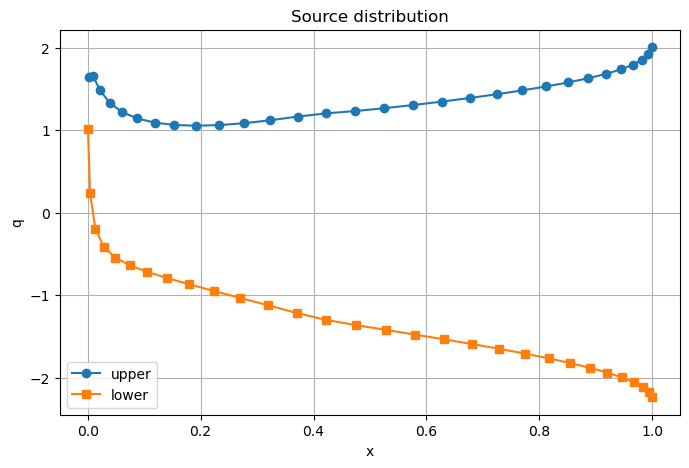

In [10]:
half = len(q_moran) // 2

plt.figure(figsize=(8, 5))

plt.plot(x_mid_moran[:half], q_moran[:half], "o-", label="upper")
plt.plot(x_mid_moran[half:], q_moran[half:], "s-", label="lower")

plt.xlabel("x")
plt.ylabel("q")
plt.title("Source distribution")
plt.legend()
plt.grid(True)
plt.show()

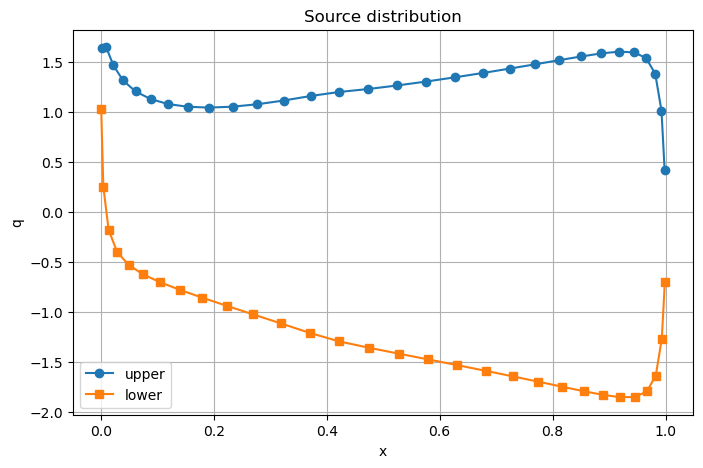

In [11]:
half = len(q_mason) // 2

plt.figure(figsize=(8, 5))

plt.plot(x_mid_mason[:half], q_mason[:half], "o-", label="upper")
plt.plot(x_mid_mason[half:], q_mason[half:], "s-", label="lower")

plt.xlabel("x")
plt.ylabel("q")
plt.title("Source distribution")
plt.legend()
plt.grid(True)
plt.show()

## 7. Tangential velocity and pressure coefficient

$$
C_p = 1 - \left(\frac{V_t}{U_\infty}\right)^2
$$

Also check if the Kutta condition is satisfied at the trailing edge.

In [12]:
# velocity

In [13]:
Vt_moran = (
    At_moran @ q_moran
    + gamma_moran * np.sum(Bt_moran, axis=1)
    + np.cos(alpha - theta_moran)
)

Cp_moran = 1 - Vt_moran**2

print("Kutta check =", Vt_moran[0] + Vt_moran[-1])
print("Cp min/max =", Cp_moran.min(), Cp_moran.max())

Kutta check = -3.3306690738754696e-16
Cp min/max = -2.2492954577322766 0.9967889952864325


In [14]:
Vt_mason = (
    At_mason @ q_mason
    + gamma_mason * np.sum(Bt_mason, axis=1)
    + np.cos(alpha - theta_mason)
)

Cp_mason = 1 - Vt_mason**2

print("Kutta check =", Vt_mason[0] + Vt_mason[-1])
print("Cp min/max =", Cp_mason.min(), Cp_mason.max())

Kutta check = -4.440892098500626e-16
Cp min/max = -2.192868085489433 0.9984496034141901


### 7.1 Plot pressure coefficient

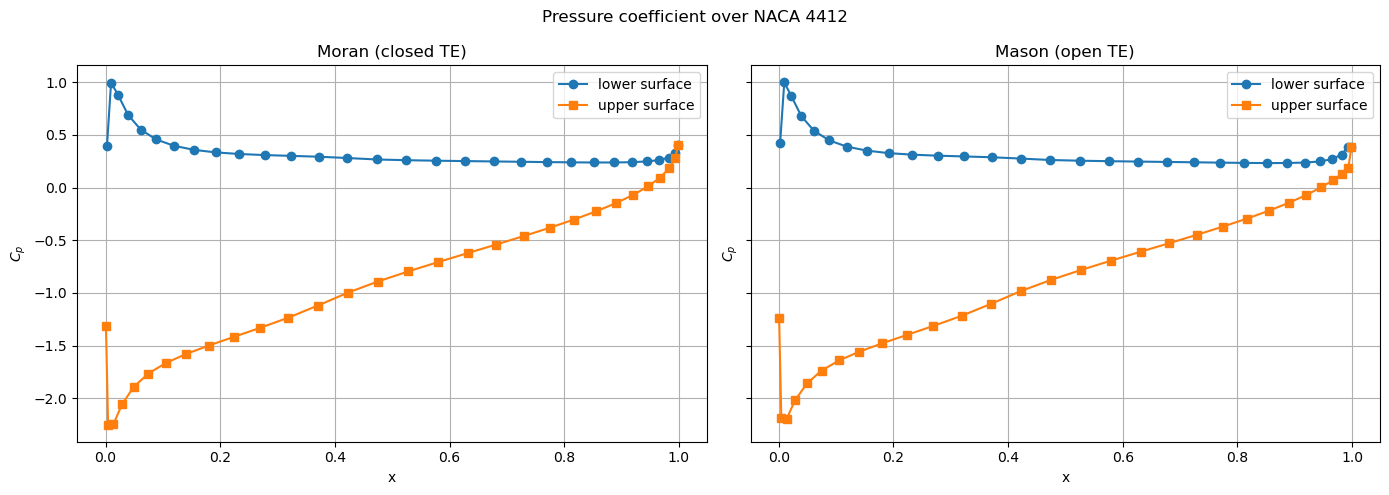

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# MORAN

N_panels_moran = len(ds_moran)
half_moran = N_panels_moran // 2

x_upper_moran = x_mid_moran[:half_moran]
Cp_upper_moran = Cp_moran[:half_moran]

x_lower_moran = x_mid_moran[half_moran:]
Cp_lower_moran = Cp_moran[half_moran:]

upper_order_moran = np.argsort(x_upper_moran)
lower_order_moran = np.argsort(x_lower_moran)

axes[0].plot(
    x_upper_moran[upper_order_moran],
    Cp_upper_moran[upper_order_moran],
    "o-",
    label="lower surface"
)

axes[0].plot(
    x_lower_moran[lower_order_moran],
    Cp_lower_moran[lower_order_moran],
    "s-",
    label="upper surface"
)

axes[0].invert_yaxis()
axes[0].set_xlabel("x")
axes[0].set_ylabel("$C_p$")
axes[0].set_title("Moran (closed TE)")
axes[0].legend()
axes[0].grid(True)

# MASON

N_panels_mason = len(ds_mason)
half_mason = N_panels_mason // 2

x_upper_mason = x_mid_mason[:half_mason]
Cp_upper_mason = Cp_mason[:half_mason]

x_lower_mason = x_mid_mason[half_mason:]
Cp_lower_mason = Cp_mason[half_mason:]

upper_order_mason = np.argsort(x_upper_mason)
lower_order_mason = np.argsort(x_lower_mason)

axes[1].plot(
    x_upper_mason[upper_order_mason],
    Cp_upper_mason[upper_order_mason],
    "o-",
    label="lower surface"
)

axes[1].plot(
    x_lower_mason[lower_order_mason],
    Cp_lower_mason[lower_order_mason],
    "s-",
    label="upper surface"
)

axes[1].invert_yaxis()
axes[1].set_xlabel("x")
axes[1].set_ylabel("$C_p$")
axes[1].set_title("Mason (open TE)")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Pressure coefficient over NACA 4412")
plt.tight_layout()

plt.show()

## 8. Lift coefficient using Kutta–Joukowski

For nondimensional chord $L=1$ and $U_\infty=1$, a common coefficient relation is:

$$
C_L = 2\Gamma
$$

Check your sign convention.

In [16]:
U_inf = 1.0
chord = 1.0

Gamma_moran = gamma_moran * np.sum(ds_moran)
CL_kj_moran = 2 * Gamma_moran / (U_inf * chord)

Gamma_mason = gamma_mason * np.sum(ds_mason)
CL_kj_mason = 2 * Gamma_mason / (U_inf * chord)

print("Moran:")
print("Gamma =", Gamma_moran)
print("CL from Kutta-Joukowski =", CL_kj_moran)

print("\nMason:")
print("Gamma =", Gamma_mason)
print("CL from Kutta-Joukowski =", CL_kj_mason)

Moran:
Gamma = 0.6212137093981014
CL from Kutta-Joukowski = 1.2424274187962028

Mason:
Gamma = 0.6087368580832535
CL from Kutta-Joukowski = 1.217473716166507


## 9. Net pressure force, lift, and drag

In [17]:
def pressure_force_coefficients(Cp, ds, sin_theta, cos_theta, alpha):
    """
    Compute pressure force coefficients from Cp.

    Returns:
    Cx, Cy : force coefficients in x/y directions
    CL, CD : lift and drag coefficients
    """

    # outward normal for clockwise panels
    nx = sin_theta
    ny = -cos_theta

    # pressure force acts inward, opposite to outward normal
    dCx = Cp * nx * ds
    dCy = Cp * ny * ds

    Cx = np.sum(dCx)
    Cy = np.sum(dCy)

    # rotate x/y force into drag/lift directions
    CD = Cx * np.cos(alpha) + Cy * np.sin(alpha)
    CL = -Cx * np.sin(alpha) + Cy * np.cos(alpha)

    return Cx, Cy, CL, CD

In [18]:
Cx_moran, Cy_moran, CL_p_moran, CD_p_moran = pressure_force_coefficients(
    Cp_moran,
    ds_moran,
    sin_moran,
    cos_moran,
    alpha
)

print("Moran:")
print("Cx =", Cx_moran)
print("Cy =", Cy_moran)
print("CL pressure =", CL_p_moran)
print("CD pressure =", CD_p_moran)
print("|CD/CL| =", abs(CD_p_moran / CL_p_moran))

Moran:
Cx = -0.12931436505362853
Cy = 1.206155879270884
CL pressure = 1.2130654630195539
CD pressure = -0.002528346910048579
|CD/CL| = 0.002084262545695626


In [19]:
Cx_mason, Cy_mason, CL_p_mason, CD_p_mason = pressure_force_coefficients(
    Cp_mason,
    ds_mason,
    sin_mason,
    cos_mason,
    alpha
)

print("Mason:")
print("Cx =", Cx_mason)
print("Cy =", Cy_mason)
print("CL pressure =", CL_p_mason)
print("CD pressure =", CD_p_mason)
print("|CD/CL| =", abs(CD_p_mason / CL_p_mason))

Mason:
Cx = -0.12557430732525368
Cy = 1.1885225889036046
CL pressure = 1.1951378271750288
CD pressure = -0.0006519583536824941
|CD/CL| = 0.0005455089269691523


## 10. Pressure field and velocity vectors

In [20]:
from matplotlib.path import Path

def velocity_at_points(X, Y, x_nodes, y_nodes, ds, sin_theta, cos_theta, q, gamma, alpha, U_inf=1.0):
    """
    Compute velocity field at grid points X,Y.
    Uses source panels + constant vortex strength.
    """

    U = U_inf * np.cos(alpha) * np.ones_like(X)
    V = U_inf * np.sin(alpha) * np.ones_like(Y)

    N = len(ds)

    for j in range(N):
        dx = X - x_nodes[j]
        dy = Y - y_nodes[j]

        # global -> local panel-j coordinates
        x_local = dx * cos_theta[j] + dy * sin_theta[j]
        y_local = -dx * sin_theta[j] + dy * cos_theta[j]

        r1 = np.sqrt(x_local**2 + y_local**2)
        r2 = np.sqrt((x_local - ds[j])**2 + y_local**2)

        # avoid log singularities
        r1 = np.maximum(r1, 1e-12)
        r2 = np.maximum(r2, 1e-12)

        theta1 = np.arctan2(y_local, x_local)
        theta2 = np.arctan2(y_local, x_local - ds[j])

        beta = theta2 - theta1
        beta = (beta + np.pi) % (2*np.pi) - np.pi

        logterm = np.log(r2 / r1)

        # local velocity influence
        u_source = logterm / (2*np.pi)
        v_source = beta / (2*np.pi)

        u_vortex = -beta / (2*np.pi)
        v_vortex = logterm / (2*np.pi)

        # local -> global
        u_s = u_source * cos_theta[j] - v_source * sin_theta[j]
        v_s = u_source * sin_theta[j] + v_source * cos_theta[j]

        u_v = u_vortex * cos_theta[j] - v_vortex * sin_theta[j]
        v_v = u_vortex * sin_theta[j] + v_vortex * cos_theta[j]

        U += q[j] * u_s + gamma * u_v
        V += q[j] * v_s + gamma * v_v

    return U, V

def mask_inside_airfoil(X, Y, x_nodes, y_nodes):
    points = np.vstack([X.ravel(), Y.ravel()]).T
    polygon = Path(np.column_stack([x_nodes, y_nodes]))
    inside = polygon.contains_points(points).reshape(X.shape)
    return inside

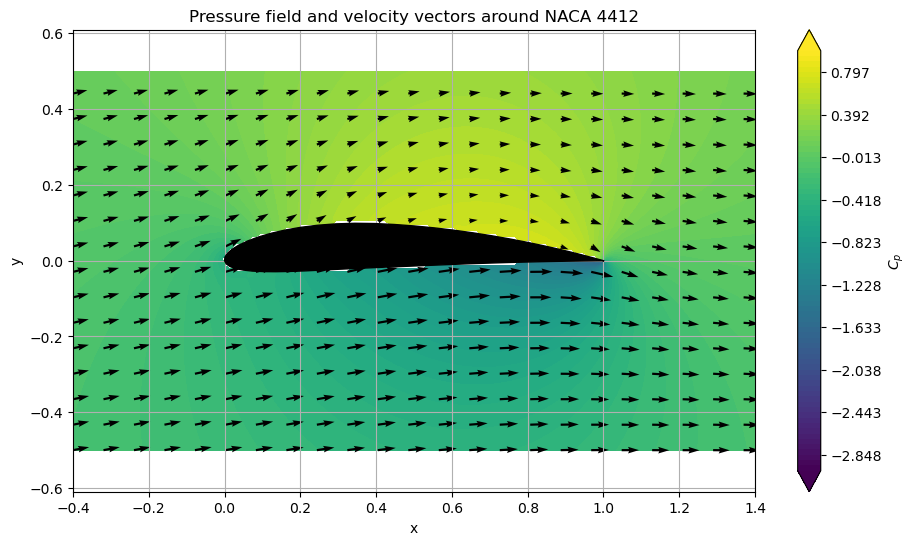

In [21]:
# grid
x_grid = np.linspace(-0.4, 1.4, 180)
y_grid = np.linspace(-0.5, 0.5, 120)
X, Y = np.meshgrid(x_grid, y_grid)

U, V = velocity_at_points(
    X, Y,
    x_nodes_moran, y_nodes_moran,
    ds_moran,
    sin_moran,
    cos_moran,
    q_moran,
    gamma_moran,
    alpha
)

inside = mask_inside_airfoil(X, Y, x_nodes_moran, y_nodes_moran)

U_masked = U.copy()
V_masked = V.copy()
U_masked[inside] = np.nan
V_masked[inside] = np.nan

Cp_field = 1 - (U_masked**2 + V_masked**2)

plt.figure(figsize=(11, 6))

cont = plt.contourf(
    X, Y, Cp_field,
    levels=np.linspace(-3, 1, 80),
    extend="both"
)

plt.colorbar(cont, label="$C_p$")

# velocity vectors, downsampled
skip = 8
plt.quiver(
    X[::skip, ::skip],
    Y[::skip, ::skip],
    U_masked[::skip, ::skip],
    V_masked[::skip, ::skip],
    scale=45
)

plt.fill(x_nodes_moran, y_nodes_moran, "k", zorder=3)
plt.plot(x_nodes_moran, y_nodes_moran, "k-", linewidth=1)

plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Pressure field and velocity vectors around NACA 4412")
plt.grid(True)
plt.show()

## 11. Streamlines

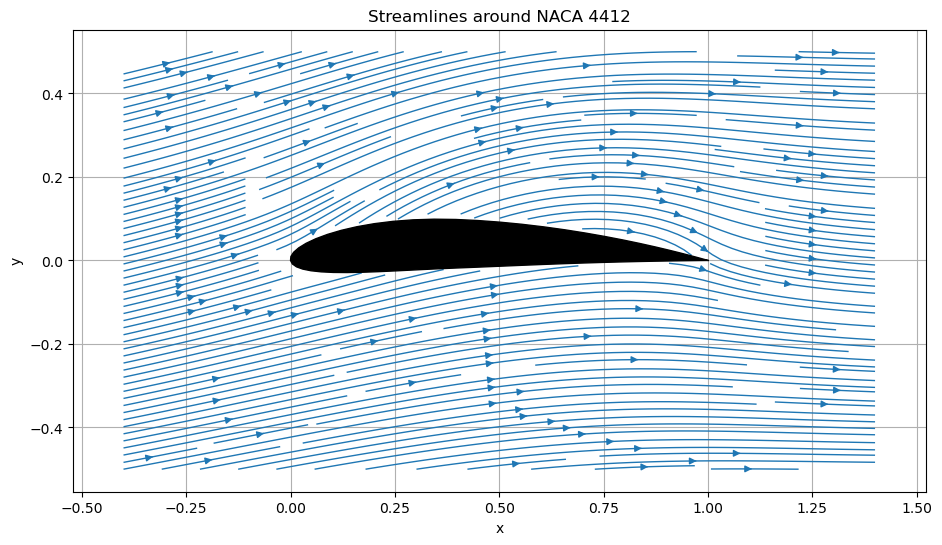

In [22]:
speed = np.sqrt(U_masked**2 + V_masked**2)

plt.figure(figsize=(11, 6))

plt.streamplot(
    X, Y,
    U_masked,
    V_masked,
    density=2,
    linewidth=1,
    arrowsize=1
)

plt.fill(x_nodes_moran, y_nodes_moran, "k", zorder=3)
plt.plot(x_nodes_moran, y_nodes_moran, "k-", linewidth=1)

plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Streamlines around NACA 4412")
plt.grid(True)
plt.show()

## 12. Vary angle of attack

Task:

$$
\alpha \in [-5^\circ,15^\circ]
$$

Plot $C_L$ versus $\alpha$.

In [46]:
def solve_case(N, alpha_deg, epsilon=0.04, p=0.4, tau=0.12, method="moran"):
    """
    Solve one Hess-Smith case.

    TODO:
    call geometry, panel geometry, system assembly, solve,
    pressure coefficient, and force calculation.
    """

    alpha = np.deg2rad(alpha_deg)

    # airfoil geometry
    x_nodes, y_nodes = naca4_nodes(
        N=N,
        eps=epsilon,
        p=p,
        tau=tau,
        method=method
    )

    # panel geometry
    x_mid, y_mid, ds, sin_theta, cos_theta, theta = panel_geometry(
        x_nodes,
        y_nodes
    )

    # build Hess-Smith system
    A, b, An, At, Bn, Bt = build_matrix(
        x_nodes,
        y_nodes,
        x_mid,
        y_mid,
        ds,
        theta,
        alpha
    )

    sol = np.linalg.solve(A, b)

    q = sol[:-1]
    gamma = sol[-1]

    # tangential velocity and pressure coefficient
    Vt = (
        At @ q
        + gamma * np.sum(Bt, axis=1)
        + np.cos(alpha - theta)
    )

    Cp = 1 - Vt**2

    # pressure force coefficients
    Cx, Cy, CL_p, CD_p = pressure_force_coefficients(
        Cp,
        ds,
        sin_theta,
        cos_theta,
        alpha
    )
    
    result = {
        "alpha_deg": alpha_deg,
        "CL_p": CL_p,
        "CD_p": CD_p,
        "gamma": gamma,
    }

    return result

In [47]:
N = 60
alphas = np.linspace(-5, 15, 21)

CL_pressure = []

for alpha_deg in alphas:
    result = solve_case(
        N=N,
        alpha_deg=alpha_deg,
        epsilon=0.04,
        p=0.4,
        tau=0.12,
        method="moran"
    )

    CL_pressure.append(result["CL_p"])

CL_pressure = np.array(CL_pressure)
for alpha, CL in zip(alphas, CL_pressure):
    print(f"alpha = {alpha:5.1f} deg,  CL = {CL:7.4f}")
# we have zero-lift around -4 deg. We will use it for a reference line

alpha =  -5.0 deg,  CL = -0.1082
alpha =  -4.0 deg,  CL =  0.0122
alpha =  -3.0 deg,  CL =  0.1327
alpha =  -2.0 deg,  CL =  0.2531
alpha =  -1.0 deg,  CL =  0.3736
alpha =   0.0 deg,  CL =  0.4939
alpha =   1.0 deg,  CL =  0.6142
alpha =   2.0 deg,  CL =  0.7344
alpha =   3.0 deg,  CL =  0.8544
alpha =   4.0 deg,  CL =  0.9742
alpha =   5.0 deg,  CL =  1.0938
alpha =   6.0 deg,  CL =  1.2131
alpha =   7.0 deg,  CL =  1.3320
alpha =   8.0 deg,  CL =  1.4507
alpha =   9.0 deg,  CL =  1.5689
alpha =  10.0 deg,  CL =  1.6867
alpha =  11.0 deg,  CL =  1.8040
alpha =  12.0 deg,  CL =  1.9208
alpha =  13.0 deg,  CL =  2.0371
alpha =  14.0 deg,  CL =  2.1528
alpha =  15.0 deg,  CL =  2.2679


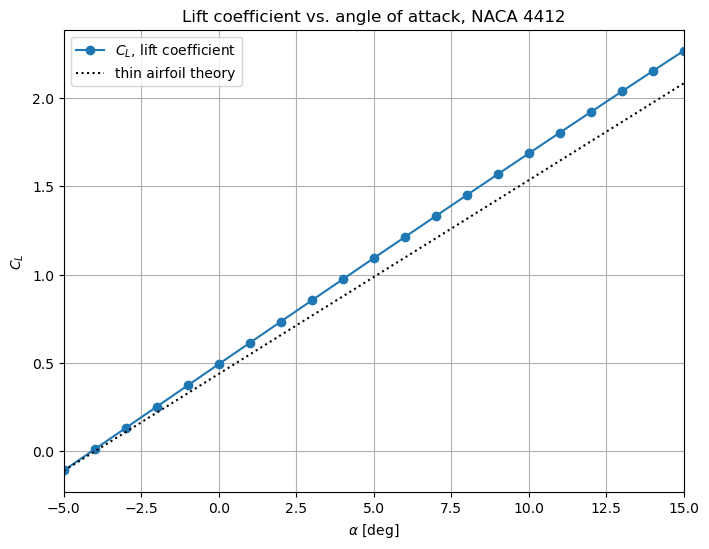

In [45]:
plt.figure(figsize=(8, 6))

plt.plot(
    alphas,
    CL_pressure,
    "o-",
    label=r"$C_L$, lift coefficient"
)

# thin airfoil theory reference line for NACA 4412
# approximate zero-lift angle for NACA 4412 is around -4 degrees
alpha_zero_lift = -4.0
CL_thin = 2 * np.pi * np.deg2rad(alphas - alpha_zero_lift)

plt.plot(
    alphas,
    CL_thin,
    "k:",
    label="thin airfoil theory"
)

plt.xlabel(r"$\alpha$ [deg]")
plt.ylabel(r"$C_L$")
plt.title(r"Lift coefficient vs. angle of attack, NACA 4412")
plt.grid(True)
plt.legend()
plt.xlim(-5, 15)

plt.show()

## 13. Vary number of panels

Task:

$$
N \in [20,100]
$$

Plot pressure lift and pressure drag coefficients versus number of panels.

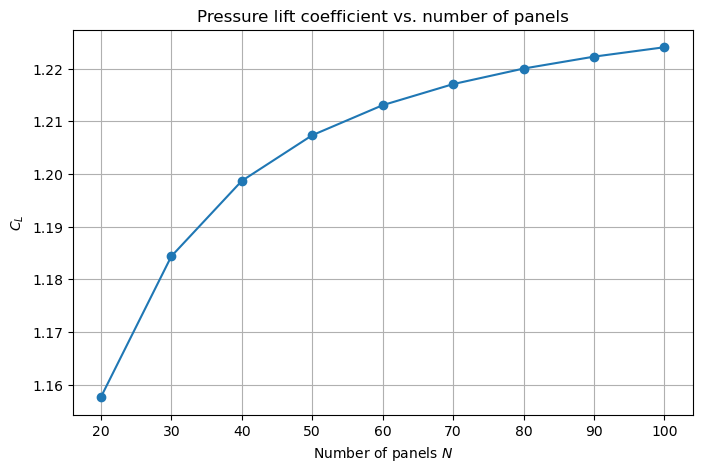

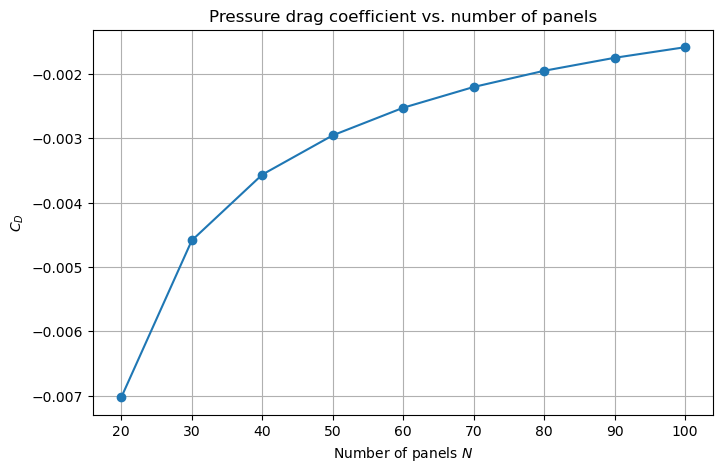

In [50]:
Ns = np.arange(20, 101, 10)
CL_N = []
CD_N = []

for n in Ns:
    res = solve_case(N=n, alpha_deg=6.0)
    CL_N.append(res["CL_p"])
    CD_N.append(res["CD_p"])

plt.figure(figsize=(8, 5))
plt.plot(Ns, CL_N, "o-")
plt.xlabel(r"Number of panels $N$")
plt.ylabel(r"$C_L$")
plt.title(r"Pressure lift coefficient vs. number of panels")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(Ns, CD_N, "o-")
plt.xlabel(r"Number of panels $N$")
plt.ylabel(r"$C_D$")
plt.title(r"Pressure drag coefficient vs. number of panels")
plt.grid(True)
plt.show()

## 14. Runtime measurement

In [51]:
def run_all_tasks_for_timing():
    """
    Run all numerical tasks from the assignment.

    The goal is to measure the execution time of the written code without plots display.
    """

    # Task 1: airfoil nodes

    N = 60
    epsilon = 0.04
    p = 0.4
    tau = 0.12
    alpha_deg = 6.0
    alpha = np.deg2rad(alpha_deg)

    x_nodes, y_nodes = naca4_nodes(
        N=N,
        eps=epsilon,
        p=p,
        tau=tau,
        method="moran"
    )

    # Task 2: panel geometry

    x_mid, y_mid, ds, sin_theta, cos_theta, theta = panel_geometry(
        x_nodes,
        y_nodes
    )

    # Task 3: build matrix and RHS

    A, b, An, At, Bn, Bt = build_matrix(
        x_nodes,
        y_nodes,
        x_mid,
        y_mid,
        ds,
        theta,
        alpha
    )

    # Task 4: solve for source strengths and vortex strength

    sol = np.linalg.solve(A, b)

    q = sol[:-1]
    gamma = sol[-1]

    # Task 5: tangential velocity and pressure coefficient

    Vt = (
        At @ q
        + gamma * np.sum(Bt, axis=1)
        + np.cos(alpha - theta)
    )

    Cp = 1 - Vt**2

    # Kutta condition check
    kutta_residual = Vt[0] + Vt[-1]

    # Task 6: lift coefficient using Kutta-Joukowski theorem

    Gamma_total = gamma * np.sum(ds)
    CL_kj = 2 * Gamma_total

    # Task 7: net pressure force, pressure lift and drag

    Cx, Cy, CL_p, CD_p = pressure_force_coefficients(
        Cp,
        ds,
        sin_theta,
        cos_theta,
        alpha
    )

    # Task 8: pressure field and velocity vectors

    x_grid = np.linspace(-0.4, 1.4, 180)
    y_grid = np.linspace(-0.5, 0.5, 120)
    X, Y = np.meshgrid(x_grid, y_grid)

    U, V = velocity_at_points(
        X,
        Y,
        x_nodes,
        y_nodes,
        ds,
        sin_theta,
        cos_theta,
        q,
        gamma,
        alpha
    )

    inside = mask_inside_airfoil(X, Y, x_nodes, y_nodes)

    U_masked = U.copy()
    V_masked = V.copy()

    U_masked[inside] = np.nan
    V_masked[inside] = np.nan

    Cp_field = 1 - (U_masked**2 + V_masked**2)

    # Task 9: streamlines

    # For timing, we create the streamline object and immediately close the figure.
    # This includes the cost of streamline computation, but avoids displaying it.
    fig, ax = plt.subplots()
    ax.streamplot(
        X,
        Y,
        U_masked,
        V_masked,
        density=2,
        linewidth=1,
        arrowsize=1
    )
    plt.close(fig)

    # Task 10: vary angle of attack

    alphas = np.linspace(-5, 15, 21)

    CL_alpha = []

    for a_deg in alphas:
        result = solve_case(
            N=60,
            alpha_deg=a_deg,
            epsilon=epsilon,
            p=p,
            tau=tau,
            method="moran"
        )

        CL_alpha.append(result["CL_p"])

    CL_alpha = np.array(CL_alpha)

    # Task 11: vary number of panels

    Ns = np.arange(20, 101, 10)

    CL_N = []
    CD_N = []

    for n in Ns:
        result = solve_case(
            N=n,
            alpha_deg=6.0,
            epsilon=epsilon,
            p=p,
            tau=tau,
            method="moran"
        )

        CL_N.append(result["CL_p"])
        CD_N.append(result["CD_p"])

    CL_N = np.array(CL_N)
    CD_N = np.array(CD_N)

    return {
        "q": q,
        "gamma": gamma,
        "Cp": Cp,
        "Vt": Vt,
        "kutta_residual": kutta_residual,
        "CL_kj": CL_kj,
        "CL_p": CL_p,
        "CD_p": CD_p,
        "Cp_field": Cp_field,
        "CL_alpha": CL_alpha,
        "CL_N": CL_N,
        "CD_N": CD_N,
    }

In [52]:
t0 = time.perf_counter()

timing_results = run_all_tasks_for_timing()

t1 = time.perf_counter()
print(f"Total runtime: {t1 - t0:.4f} s")

Total runtime: 3.4094 s


## 15. Report checklist

- [ ] NACA 4412 geometry and node distribution
- [ ] panel geometry
- [ ] Hess–Smith system construction
- [ ] source distribution plot
- [ ] tangential velocity and pressure coefficient
- [ ] Kutta condition check
- [ ] lift from Kutta–Joukowski
- [ ] pressure force, lift, drag
- [ ] pressure field and velocity vectors
- [ ] streamlines
- [ ] lift coefficient vs angle of attack
- [ ] lift and drag vs number of panels
- [ ] runtime measurement